In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Q1

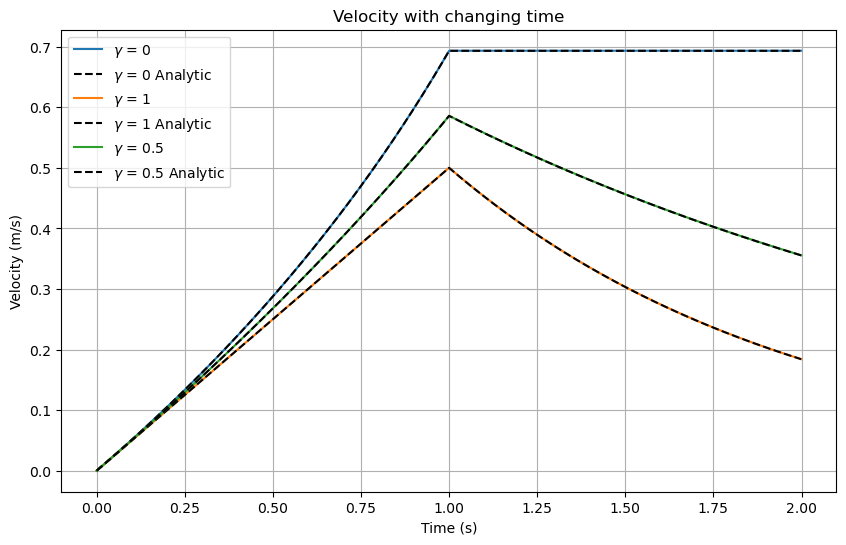

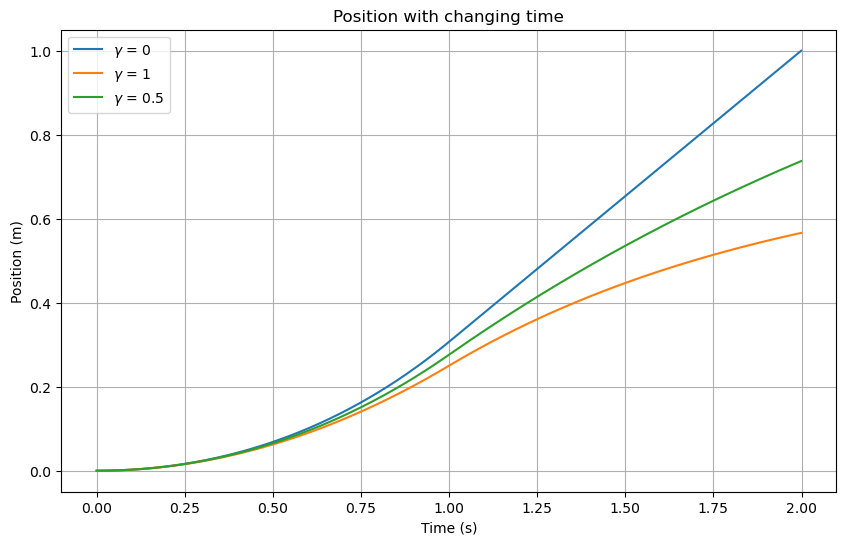

In [9]:
#Q1
gamma = 0
m0 = 1 #kg, 
a = 1 #kg s−1
vrel = 1 #m s−1
T = m0/a
#functions 

def v_T(gamma):
    if gamma != 0:
        return vrel*a*(1 - (1/2)**(gamma/a))/gamma
    else:
        return vrel*np.log(2)

def velocity(t, gamma):
    if t <= T:
        if gamma != 0:
            return vrel*a*((1 - (1 - t/(2*T))**(gamma/a)))/gamma
        else:
            return vrel*np.log((2*m0)/(2*m0 - a*t))
    else:
        return velocity(T, gamma)*np.exp(-gamma*(t-T)/m0)

def mass(t):
    if t <= T:
        return 2*m0 - a*t
    else:
        return m0

def g(t,y):  #derivative function for euler and rk4
    if t<=T:
        return np.asarray([y[1], (vrel*a - gamma*y[1])/mass(t)])
    else:
        return np.asarray([y[1], (-gamma*y[1])/mass(t)])

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

h = 1.0e-3
t0 = 0.0
tf = 2

ts = np.arange(t0, tf, h)
N = len(ts)

y_ini = np.array([0, 0])  # Initial condition 

# Call the methods
fig1, ax1 = plt.subplots(figsize = (10,6))
gamma_vals = [0, a, a/2]
for gamma_val in gamma_vals:
    gamma = gamma_val
    vs = caller_rk(rk4, g, y_ini, N, ts, h)
    ax1.plot(ts, vs[:,1], label = f"$\\gamma$ = {gamma_val}")
    ax1.plot(ts, [velocity(t, gamma) for t in ts], color = "k", ls = "--",label = f"$\\gamma$ = {gamma_val} Analytic")
plt.title("Velocity with changing time")
plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.grid()
plt.legend()
plt.show()

fig2, ax2 = plt.subplots(figsize = (10,6))
gamma_vals = [0, a, a/2]
for gamma_val in gamma_vals:
    gamma = gamma_val
    vs = caller_rk(rk4, g, y_ini, N, ts, h)
    ax2.plot(ts, vs[:,0], label = f"$\\gamma$ = {gamma_val}")
plt.title("Position with changing time")
plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.grid()
plt.legend()
plt.show()

# Q2

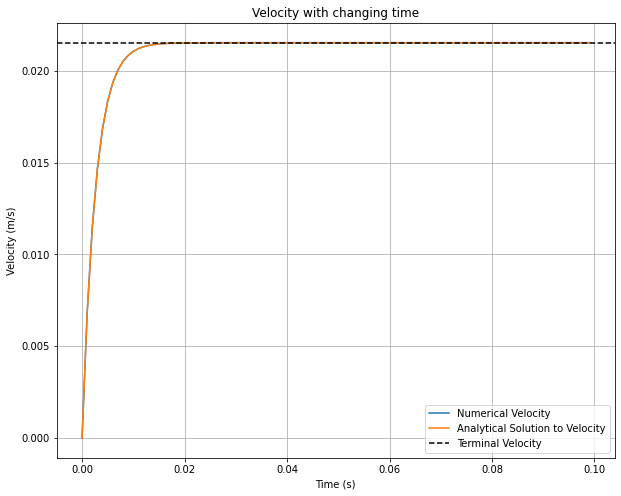

The numerical solution to t* is 0.0125
The analytical solution to t* is 0.012053801157955407
Using Trapezoid Method x* is --> 0.00021297463269819697
The analytical solution to x* is 0.0002133281954866898
We can see that our numerical and analytical solutions are in agreement with each other


In [2]:
#Q2
#constants
r = 1.5*1e-3 #m
rho_s = 7800
rho_f = 1260
visc = 1.49
g = 9.81
v_t = 0.021529328859060403 #2*(r**2)*(rho_s - rho_f)*g/(9*visc)
T = 0.00261744966442953 #2*(r**2)*rho_s/(9*visc)

#defining our functions

def f(t, v):
    return (v_t - v)/T

def velocity(ts):
    vel = np.zeros_like(ts)
    vel = v_t*(1 - np.exp(-ts/T))
    return vel

def root_t(t):
    return velocity(t) - 0.99*v_t

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

t0 = 0
tf = 0.10
h = 1.0e-3

ts = np.arange(t0,tf,h)
N = len(ts)
v_ini = np.array([0])

#plotting velocity with respect to time
vs = caller_rk(rk4, f, v_ini, N, ts, h)
fig, ax = plt.subplots(figsize = (10,8))
ax.plot(ts, vs, label = "Numerical Velocity")
ax.plot(ts, velocity(ts), label = "Analytical Solution to Velocity")
plt.axhline(v_t, label = "Terminal Velocity", ls = "--", color = "k")
plt.title("Velocity with changing time")
plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.grid()
plt.legend()
plt.show()


#defining our error margin and maximum iterations
eps = 1.0E-04
maxiter = 50

def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c, iteration

t_star, _ = bisection(root_t,0,0.02, eps, maxiter)
print(f"The numerical solution to t* is {t_star}") 
print(f"The analytical solution to t* is {T*np.log(100)}")


def trapezoid(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(2*np.sum(f(x)) - f(x[0]) - f(x[-1]))/2)

print(f"Using Trapezoid Method x* is --> {trapezoid(velocity,0,t_star,10)}")
print(f"The analytical solution to x* is {v_t*(t_star - 0.99*T)}")

print("We can see that our numerical and analytical solutions are in agreement with each other")

# Q3

The approximate floor of the valley is at a potential equivalent of 0.75
No, the particle is not able to surmount the right hill in the absence of drag


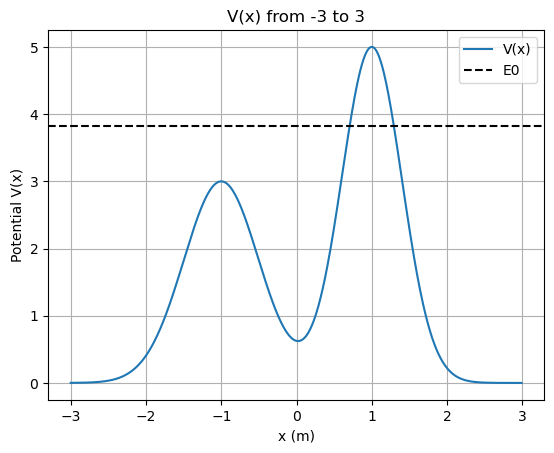

In [2]:
#Q3
#constants
m = 1
v_1 = 3
sigma_1 = 0.5
v_2 = 5
sigma_2 = 0.4
b = 1
gamma = 0.3
x0 = -0.5
v0 = 2

def V(x):
    hill_1 = v_1*np.exp(-(x +b)**2 / (2 * sigma_1**2))
    hill_2 = v_2*np.exp(-(x -b)**2 / (2 * sigma_2**2))
    return hill_1 + hill_2

def F(x):
    f_1 = v_1*(x+b)*np.exp(-(x +b)**2 / (2 * sigma_1**2))/(sigma_1**2)
    f_2 = v_2*(x-b)*np.exp(-(x -b)**2 / (2 * sigma_2**2))/(sigma_2**2)
    return f_1 + f_2
V0 = V(x0)
E0 = (m * v0**2)/2 + V0 

xs = np.arange(-3,3,0.01)
plt.plot(xs, V(xs), label = "V(x)")
plt.title("V(x) from -3 to 3")
plt.xlabel("x (m)")
plt.ylabel("Potential V(x)")
plt.grid()
plt.axhline(E0, color = "k", ls = "--", label = "E0")
plt.legend()
print("The approximate floor of the valley is at a potential equivalent of 0.75")
print("No, the particle is not able to surmount the right hill in the absence of drag")

def f(t, V):
    x, v = V
    return np.array([v, (F(x) - gamma*v)/m])

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h/2, y + k1/2)
    k3 = h * f1(x + h/2, y + k2/2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2*k2 + 2*k3 + k4)/6

def caller_rk(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

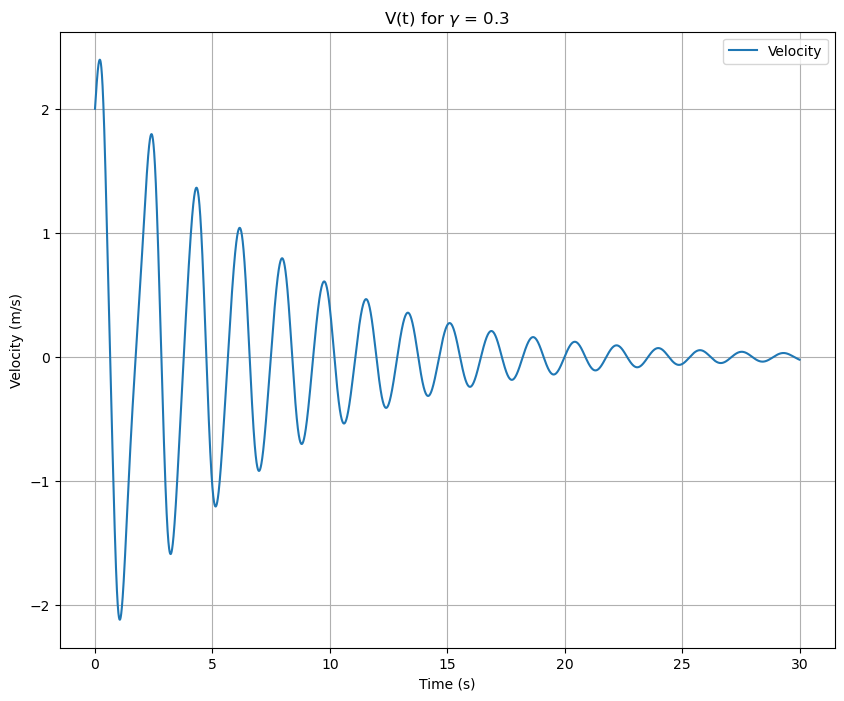

So we can see the particle's velocity is that of a damped harmonic oscillator, evertime it hits the right wall, velocity flips its sign, and it moves and then hits the left wall, and continues to repeat this motion
The particle changes its velocity roughly every second


In [3]:
t0 = 0
tf = 30
h = 1.0e-3

ts = np.arange(t0,tf,h)
N = len(ts)
v_ini = np.array([x0, v0])

gamma = 0.3
VS = caller_rk(rk4, f, v_ini, N, ts, h)
fig, ax = plt.subplots(figsize = (10,8))
ax.plot(ts, VS[:,1], label = "Velocity")
plt.title("V(t) for $\\gamma$ = 0.3")
plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.grid()
plt.legend()
plt.show()

print("So we can see the particle's velocity is that of a damped harmonic oscillator, evertime it hits the right wall, velocity flips its sign, and it moves and then hits the left wall, and continues to repeat this motion")
print("The particle changes its velocity roughly every second")

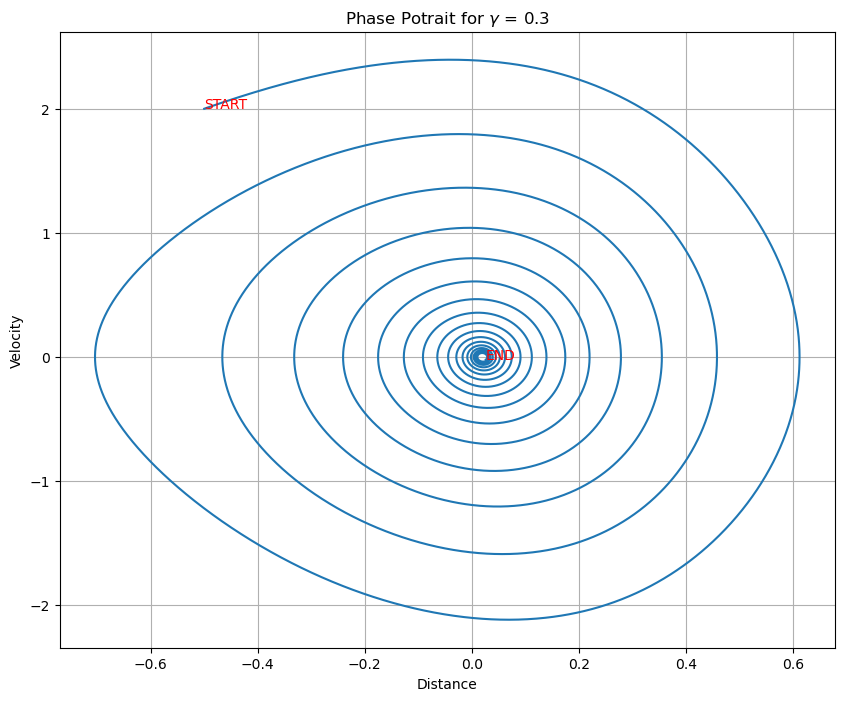

The particle is bouncing of between the right and left wall and as it decreases its energy, it slowly falls off into the pit (valley), located at approximately x = 0.This is the stable point.


In [4]:
fig1, ax1 = plt.subplots(figsize = (10,8))
ax1.plot(VS[:,0], VS[:,1])
plt.text(VS[0,0], VS[0,1], "START", color = "r")
plt.text(VS[-1,0], VS[-1,1], "END", color = "r")
plt.title("Phase Potrait for $\\gamma$ = 0.3")
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.grid()
#plt.legend()
plt.show()
print("The particle is bouncing of between the right and left wall and as it decreases its energy, it slowly falls off into the pit (valley), located at approximately x = 0.This is the stable point.")

[(0.643, 0.644), (2.825, 2.826), (4.741, 4.742)]
The three turning point are at timestamps:
0.6437134742736816 2.825733184814453 4.741476058959961
The three turning point are at locations:
0.6128067603120302 0.4584696056303784 0.3554381640131835
The three Energy values are respectively:
3.1462278372558465 2.042347167489112 1.4410525014694713


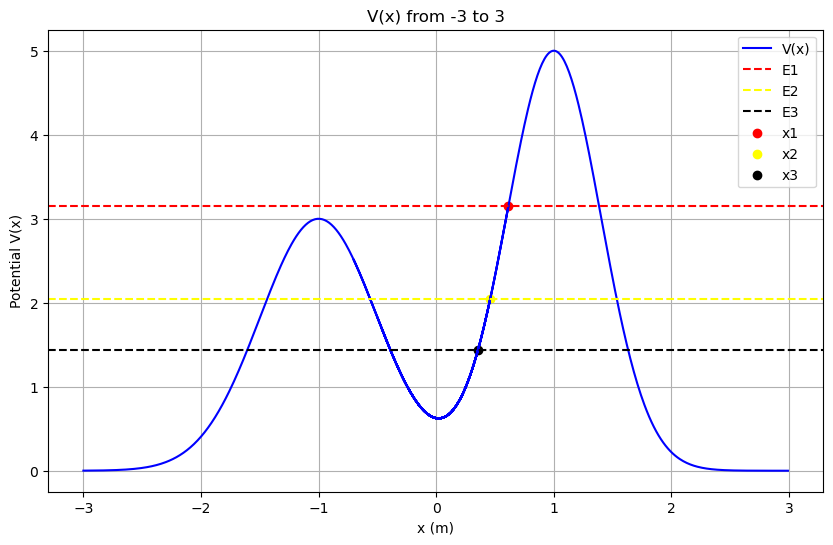

In [18]:
t0 = 0
tf = 30
h = 1.0e-3

ts = np.arange(t0,tf,h)
N = len(ts)
v_ini = np.array([x0, v0])

gamma = 0.3
VS_b = caller_rk(rk4, f, v_ini, N, ts, h)

def velocity_t(t): #since we didn't have an analytic function of V in terms of only x, it is hard to compute using bisection method, my logic of based on a given time, compute its index in the array, and then get corresponding velocity from our rk4 solution"
    #time = np.round(t/h).astype(int)
    #vel = VS_b[time, 1]
    #return vel
    return np.interp(t, ts, VS_b[:,1])
def position_t(t): 
    return np.interp(t, ts, VS_b[:,0])

#defining our error margin and maximum iterations
eps = 1.0E-06
maxiter = 100

def bisection(f,L,R,eps,maxiter):
    #f: function whose roots we are to find
    #L: left interval
    #R: right interval
    c = (L+R)/2
    iteration = 1
    while abs(f(c)) >= eps and iteration < maxiter:
        if f(L)*f(R) > 0:
            print("Bad interval!")
            return None
        if f(L)*f(c) <= 0:
            R = c
        else:
            L = c
        c = (L+R)/2
        iteration += 1
        
    if iteration == maxiter and abs(f(c)) >= eps:
        print("Failed to converge!")
        return None
    else:
        return c

intervals = []
for i in range(len(ts)-1):
    if VS_b[i,1]*VS_b[i+1,1] < 0 and VS_b[i,0] > 0:
        intervals.append((ts[i], ts[i+1]))
        if(len(intervals)==3):
            break
print(intervals)

t1 = bisection(velocity_t,0,1, eps, maxiter)
t2 = bisection(velocity_t,2,3, eps, maxiter)
t3 = bisection(velocity_t,4,5, eps, maxiter)

E1 = (m * velocity_t(t1)**2)/2 + V(position_t(t1))
E2 = (m * velocity_t(t2)**2)/2 + V(position_t(t2))
E3 = (m * velocity_t(t3)**2)/2 + V(position_t(t3))

x1 = position_t(t1)
x2 = position_t(t2)
x3 = position_t(t3)



print("The three turning point are at timestamps:")
print(t1, t2, t3)
print("The three turning point are at locations:")
print(x1, x2, x3)
print("The three Energy values are respectively:")
print(E1, E2, E3)


fig, ax = plt.subplots(figsize = (10,6))
xs = np.arange(-3,3,0.01)
plt.plot(xs, V(xs), color = "blue")
ax.plot(VS_b[:,0], V(VS_b[:,0]), label = "V(x)", color = "blue")
plt.title("V(x) from -3 to 3")
plt.xlabel("x (m)")
plt.ylabel("Potential V(x)")
plt.grid()
plt.axhline(E1,color = "r", ls = "--", label = "E1")
plt.axhline(E2, color = "yellow",ls = "--", label = "E2")
plt.axhline(E3, color = "k", ls = "--", label = "E3")
plt.scatter(x1,E1,color = "r", label = "x1")
plt.scatter(x2,E2, color = "yellow", label = "x2")
plt.scatter(x3,E3, color = "k", label = "x3")
plt.legend()

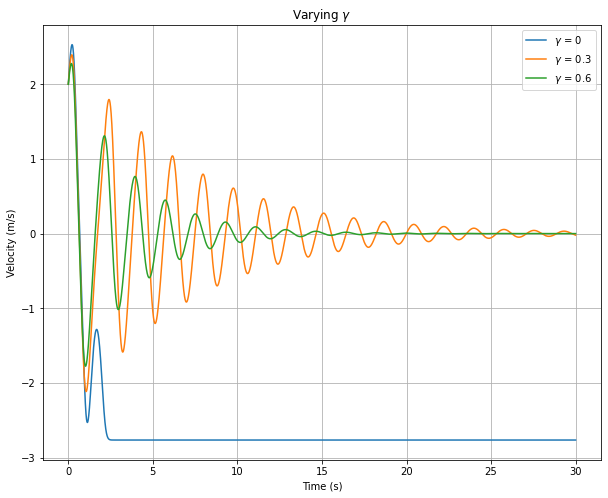

In [7]:
gamma_vals = [0,0.3,0.6]
fig, ax = plt.subplots(figsize = (10,8))
for gam in gamma_vals:
    gamma = gam
    VS = caller_rk(rk4, f, v_ini, N, ts, h)
    ax.plot(ts, VS[:,1], label = f"$\\gamma$ = {gam}")
plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.title('Varying $\\gamma$')
plt.grid()
plt.legend()
plt.show()


For $\gamma$ = 0, the particle never settles, it bounces off the walls a couple of times, and then since there is no drag it goes off into the distance


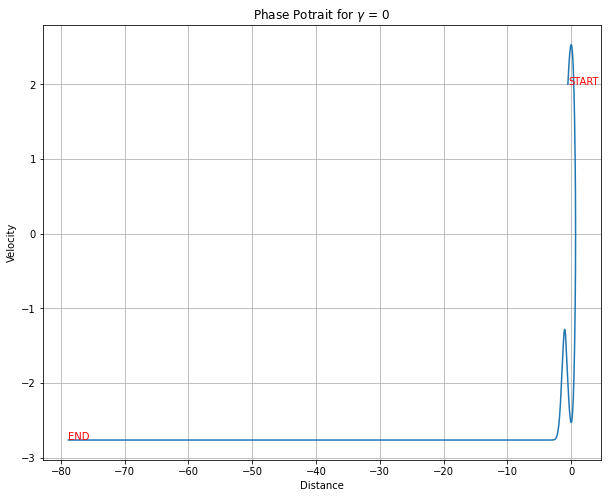

In [8]:
print(f"For $\\gamma$ = 0, the particle never settles, it bounces off the walls a couple of times, and then since there is no drag it goes off into the distance")
gamma = 0
VS = caller_rk(rk4, f, v_ini, N, ts, h)
fig1, ax1 = plt.subplots(figsize = (10,8))
ax1.plot(VS[:,0], VS[:,1])
plt.text(VS[0,0], VS[0,1], "START", color = "r")
plt.text(VS[-1,0], VS[-1,1], "END", color = "r")
plt.title("Phase Potrait for $\\gamma$ = 0")
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.grid()
#plt.legend()
plt.show()

# Q4

(-5.0, 5.0)

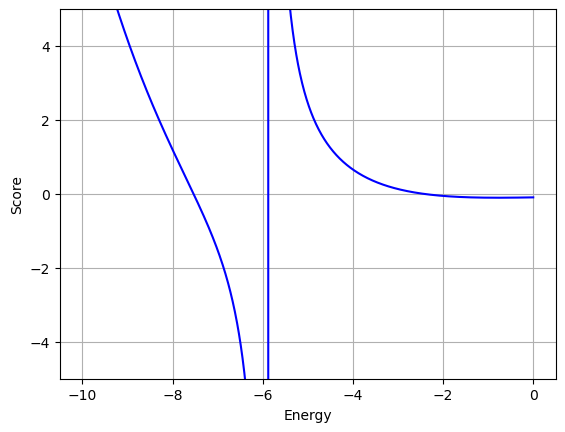

In [20]:
# The following is standard RK4. It calls a function f(x,y,k) where k is a paramter
def rk4(f,x,y,k,h):
    k1 = h*f(x,y,k)
    k2 = h*f(x + h/2, y + k1/2, k)
    k3 = h*f(x + h/2, y + k2/2, k)
    k4 = h*f(x + h, y + k3, k)
    return y + (k1+2*k2+2*k3+k4)/6

# The following is a caller function. It integrates f from xlim[0] to xlim[1] with initial condition yini. 
# The parameter k is included in the argument along with the number of points N.
def caller_rk4(f,xlim,yini,k,N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N,len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

# The following function calculates the departure from the boundary condition at the other end.
def score(k,f,ybound):
    xs, ys = caller_rk4(f,xlim,yini,k,N)
    return ys[-1][0] - ybound[1]
    
# This is an implementation of the secant method used for finding the root of the function score. 
def secant(ks,f,method,ybound):
    k1, k2 = ks
    iter = 0
    while abs(method(k2,f,ybound))>tol and iter<maxiter:
        f1 = method(k1,f,ybound)
        f2 = method(k2,f,ybound)
        k1, k2 = k2, (f2*k1 - f1*k2)/(f2 - f1)
        iter += 1
        #print(iter, k1, k2, method(k2,f,ybound))
    if iter == maxiter:
        return iter, None
    else:
        return iter, k2

# The following is an implementation of Simpson's 1/3 method (for normalization)
def simp13(y,h):
    store = y[0]**2 + y[-1]**2
    for i in range(2,len(y)):
        if i%2==0:
            store += 4*y[i]**2
        else:
            store += 2*y[i]**2
    return store*(h/3)

# The rhs of Schoedinger equation (using vectorized form)
def odefun2(x,y,E):
    k2 = E - pot(x);
    return np.array([y[1], -k2 * y[0]]) 

# The potential
def pot(x):
    if abs(x)>Lo:
        return 0.0
    else:
        return -Vo*np.sqrt(Lo**2 - x**2)

# The score. Note: we are integrating from the right and from the left and checking the difference at one of the turning points.
def score2(E,f,ybound):
    # Start from the left
    yini1 = (ybound[0], 1.0e-2);
    # psi_<
    xs1, ys1 = caller_rk4(odefun2,xlim,yini1,E,N)
    a = abs(xs1 + Lo/2);
    # find solution at x = Lo (left turning point)
    n1=np.where(a == np.min(a))[0][0]
    # Start from right
    yini2 = (ybound[1], 1.0e-2)
    # psi_>
    xs2, ys2 = caller_rk4(odefun2,xlim[-1::-1],yini2,E,N)
    a = abs(xs2 + Lo/2);
    # find solution at x = Lo (right turning point)
    n2=np.where(a == np.min(a))[0][0]
    # scale psi_>
    ys2 = ys1[n1][0]*ys2/ys2[n2][0]
    # return the difference of derivatives as score
    return ys1[n1][1] - ys2[n2][1]

Vo = 10.0
Lo = 1.0
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
yini = (ybound[0], 0.1) # 1.0e-2 is an arbitrary number finally adjusted by normalization
N = 129
maxiter = 50
tol = 1.0e-5

Es = np.linspace(-Vo, 0, 1000);
scores = [score2(E, odefun2, ybound) for E in Es];
plt.plot(Es,scores,'b-');
plt.grid()
plt.xlabel("Energy");
plt.ylabel("Score");
plt.ylim(-5,5)

-7.532640567113847
-2.4185868784385844


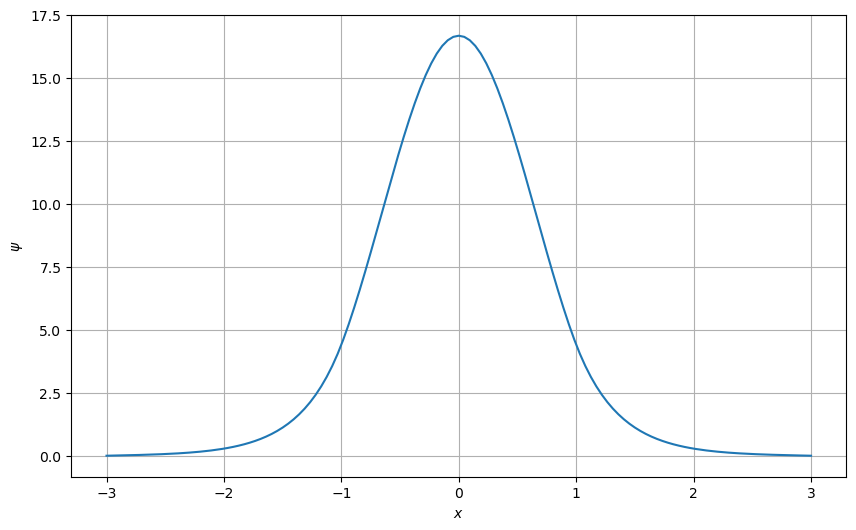

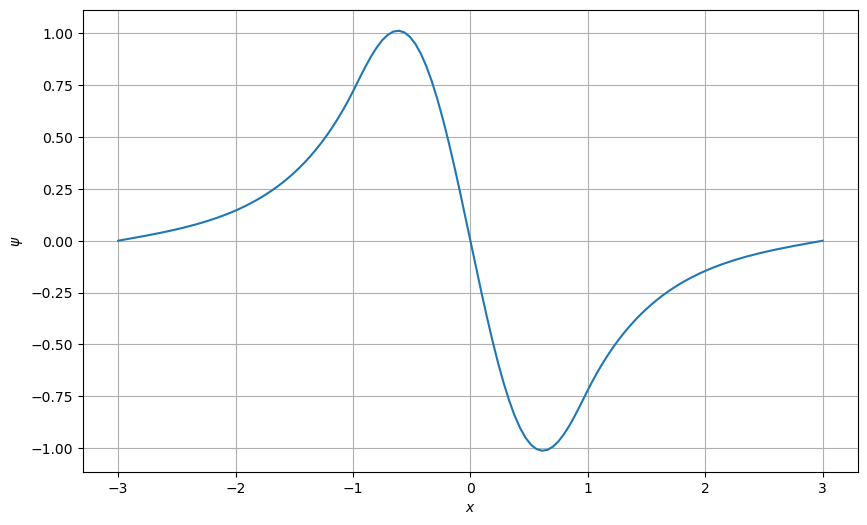

In [24]:
E_guess=[(-8,-7), (-4,-2)]
for Eini in E_guess:
    iter,Eeigen = secant(Eini,odefun2,score2,ybound);
    print(Eeigen)
    xs, ys = caller_rk4(odefun2, xlim, yini, Eeigen, N);
    y1 = [y[0] for y in ys];
    fig,ax = plt.subplots(figsize = (10,6))
    ax.plot(xs, y1);
    plt.grid();
    plt.xlabel("$x$")
    plt.ylabel("$\\psi$")